# Chapter 1 - Introduction

Scenario: an online education platform wants to predict whether a student will complete a course using information available after the first month.


## 0. Import libraries and dataset


Añado esto porque me daba error al instalar algunas librerías

In [1]:
%pip install numpy pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    GroupKFold,
    cross_val_score,
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# TODO: define the path where the dataset_alumnos.csv is stored
#DATASET_PATH = Path("entregable-ml/notebooks/dataset_alumnos.csv")
# Esta es la ruta dentro de mi proyecto, pero al estar dentro de notebooks creo que no hace falta indicar ruta
DATASET_PATH = Path("dataset_alumnos.csv")
df = pd.read_csv(DATASET_PATH)

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


## 1. Describe and visualize the dataset


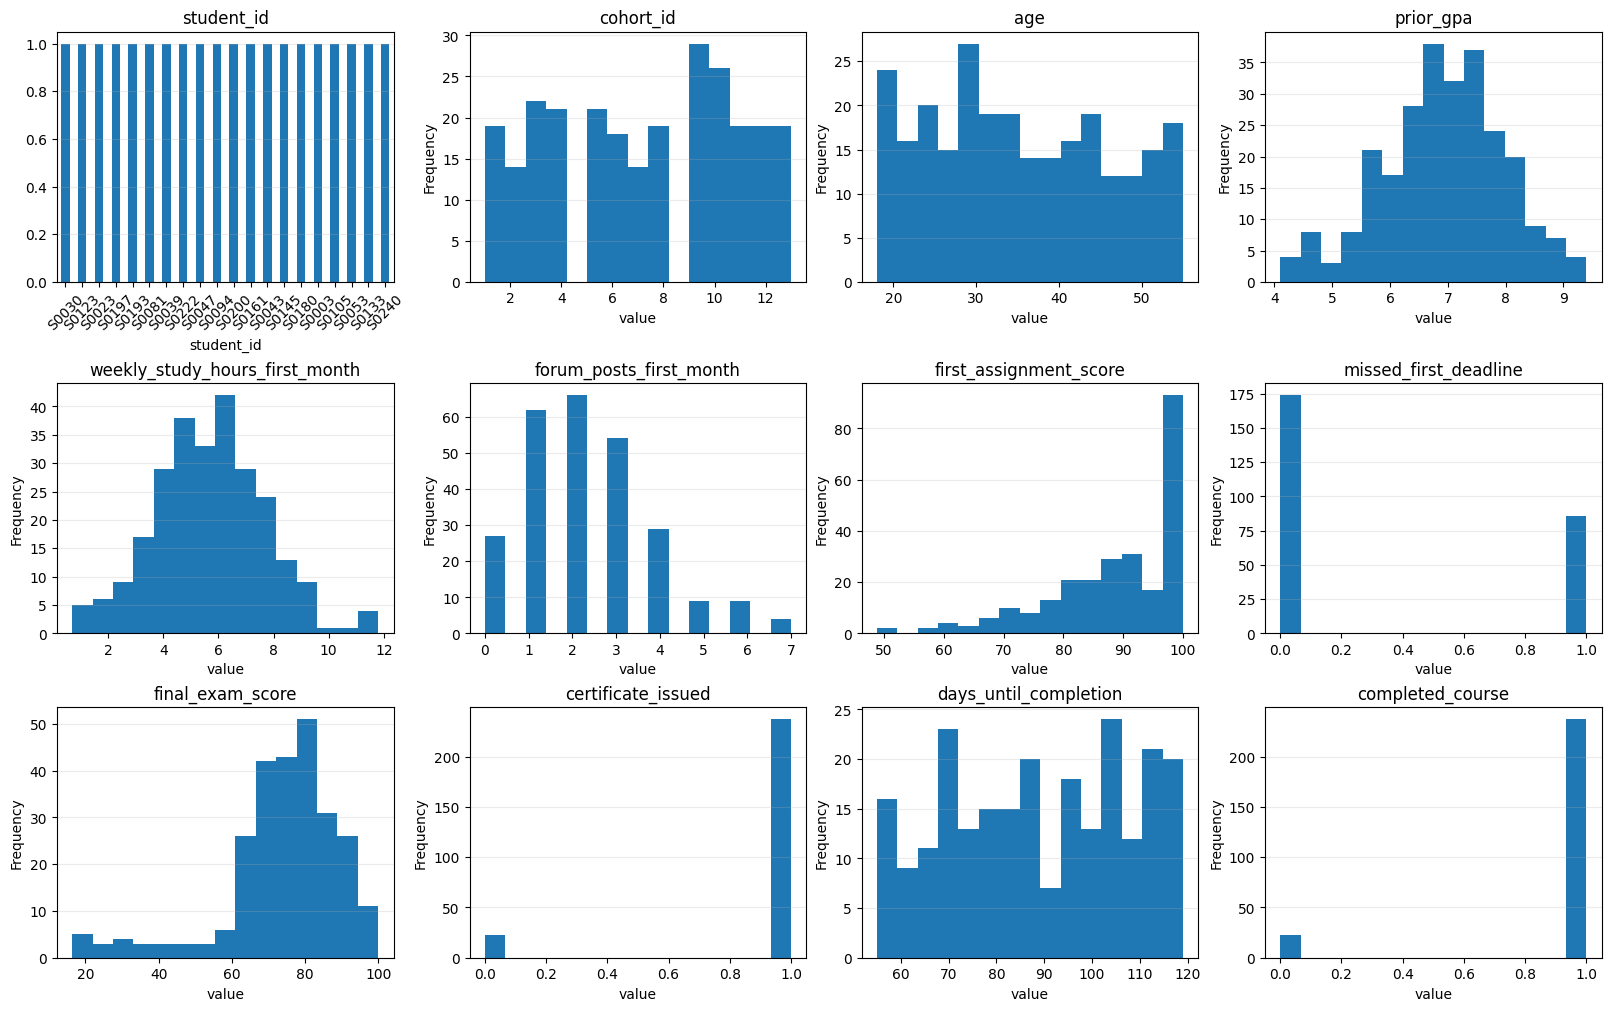

In [3]:
df.describe(include="all").T

numeric_columns = df.select_dtypes(include="number").columns
fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)

for ax, column in zip(axes.flat, df.columns):
    if column in numeric_columns:
        df[column].plot(kind="hist", bins=15, ax=ax, title=column)
        ax.set_xlabel("value")
    else:
        df[column].value_counts().head(20).plot(kind="bar", ax=ax, title=column)
        ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)

plt.show()


## 2. Formulate the problem

TODO - Complete the following questions

```text
Prediction moment: Cuando termina el primer mes

Target variable: completed_course

Is this supervised or unsupervised? Supervisado, porque queremos decir "sí o no", y no buscar patrones entre los datos. 

Is this classification or regression? Clasificación.

What information should be allowed in X? cohort_id, age, prior_gpa, weekly_study_hours_first_month, forum_post_first_month, first_assignment_score, missed_first_deadline.
```


## 3. Define column roles

Use the table below to decide what belongs in `X`, what is `y`, what is an identifier, what is a group, and what is leakage.


In [4]:
# TODO: define the valid predictors available after the first month.
# Do not include identifiers, the target, group-only columns, or leakage columns.

valid_features = [
    "cohort_id",
    "age", 
    "prior_gpa", 
    "weekly_study_hours_first_month", 
    "forum_posts_first_month", 
    "first_assignment_score",
    "missed_first_deadline"
]

target = "completed_course"
group_column = "cohort_id" #Aquí le pregunté a copilot a qué se refería con eso. 
# Ahora entiendo que se utiliza para no entrenar siempre con estudiantes de la misma clase.
leakage_features = [
    "final_exam_score", #si saca buena nota, completa el curso
    "certificate_issued", #si ha recibido el certificado o no
    "days_until_completion", #cuántos días hasta terminar su curso (si les faltan muchos días probablemente vaya a extraordinaria)
]

X = df[valid_features]
y = df[target]
groups = df[group_column]


## 4. Mistake: train and evaluate on the same rows

This block is intentionally wrong as an evaluation strategy.

It answers: “Can the model reproduce labels for rows it has already seen?”

It does not answer: “Will the model generalize?”


In [5]:
model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# TODO: fit the model using all rows in X and y
model.fit(X,y)

# TODO: predict on the same X
train_like_predictions = model.predict(X)

# TODO: compute accuracy on the same rows used for fitting
same_data_accuracy = accuracy_score(
    y, train_like_predictions
)

same_data_accuracy

1.0

TODO: Write a short interpretation:

```text
El modelo tiene una precisión del 100% porque le estamos preguntando sobre datos con los cuales el modelo ya ha sido entrenado. Por tanto no es válido para su generalización, ya que no podemos saber si el modelo funciona bien o no.
```


## 5. Train / validation / test split

We will create three sets:

```text
train       used to fit the model
validation  used to evaluate choices while developing
test        kept aside for final reporting
```

A common split is 60% / 20% / 20%.


Aquí entiendo que temporary set es train + validation (luego lo dividimos).

In [9]:
# TODO: first split: temporary set + test set
X_temp, X_test, y_temp, y_test, groups_temp, groups_test = train_test_split(
    X,
    y,
    groups,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# TODO: second split: train + validation
X_train, X_val, y_train, y_val, groups_train, groups_val = train_test_split(
    X_temp,
    y_temp,
    groups_temp,
    test_size=0.33, #0.2/0.6
    random_state=RANDOM_STATE,
    stratify=y_temp
)


TODO: Write a short justification:

```text
En el segundo TODO estratificamos y_temp, porque no podemos ver los datos del test.
```

In [12]:
def class_distribution_table(*series, names):
    rows = []
    for name, s in zip(names, series):
        counts = s.value_counts().reindex([0, 1], fill_value=0)
        rows.append({
            "split": name,
            "not_completed_0": counts.loc[0],
            "completed_1": counts.loc[1],
            "total": len(s),
        })
    return pd.DataFrame(rows)

# TODO: display the class distribution for train, validation, and test
split_distribution = class_distribution_table(
    y_train,
    y_val,
    y_test,
    names=["train", "validation", "test"]
)

split_distribution


,split,not_completed_0,completed_1,total
0,train,12,127,139
1,validation,6,63,69
2,test,5,47,52


Aquí no entiendo por qué hay que poner los vectores y_train, y_val, y_test, y no X_train, X_val, X_test.

## 6. Fit on train, evaluate on validation, reserve test

Use the validation set to estimate generalization during development.

Do not use the test set to make iterative decisions.


In [14]:
model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# TODO: fit only on train
model.fit(X_train, y_train)

# TODO: compute accuracy on train and validation
train_accuracy = accuracy_score(y_train, model.predict(X_train))
validation_accuracy = accuracy_score(y_val, model.predict(X_val))

pd.DataFrame({
    "split": ["train", "validation"],
    "accuracy": [train_accuracy, validation_accuracy]
})


,split,accuracy
0,train,1.000000
1,validation,0.753623


TODO: Write a short interpretation:

```text
Lógicamente el accuracy de los datos entrenados es del 100%. El del validation es mejorable, pero en un primer momento no parece predecir mal. Aunque habría que ver si podemos aceptar o no ese 25% de error.
```


## 7. Final test evaluation

Use the test set once you have a fixed modelling procedure.


In [15]:
# TODO: evaluate the fixed model on the test set
# Do not retrain on the test set.

test_accuracy = accuracy_score(y_test, model.predict(X_test))

test_accuracy


0.8846153846153846

Aquí ha subido el accuracy bastante con respecto al validation. (Investigar por qué).

## 8. Split variability

Repeat the train/validation split with different seeds and observe how validation accuracy changes.


In [21]:
validation_scores = []

for seed in range(20):
    # TODO: create train/validation splits from the full X, y
    # Use stratification.
    X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
        X,
        y,
        groups,
        test_size=0.2,
        random_state=seed,
        stratify=y
    )

    model = DecisionTreeClassifier(random_state=RANDOM_STATE)
    # TODO: fit and score on validation
    model.fit(X_train, y_train)
    score = accuracy_score(y_val, model.predict(X_val))
    validation_scores.append(score)

validation_scores_df = pd.DataFrame({
    "seed": range(20), "validation_accuracy": validation_scores
})
validation_scores_df.describe().loc[["min", "mean", "max", "std"]]


ValueError: too many values to unpack (expected 4)

Aquí no entiendo por qué me da error.

In [ ]:
# TODO: show the validation accuracy values visually.
# A simple line plot or histogram is enough.

...


## 9. Cross-validation

Cross-validation uses several train/validation splits internally.

Start with standard K-fold.


In [23]:
model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# TODO: define a 5-fold KFold object with shuffling
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# TODO: compute cross-validation scores
kf_scores = cross_val_score(model, X_temp, y_temp, cv=kf, scoring="accuracy")

pd.DataFrame({"fold": range(1, len(kf_scores) + 1), "accuracy": kf_scores})


,fold,accuracy
0,1,0.833333
1,2,0.952381
2,3,0.785714
3,4,0.756098
4,5,0.829268


## 10. Compare K-fold variants

Now compare several cross-validation strategies.

Use the same model and the same `X`, `y`.

Strategies to compare:

- `KFold`
- `StratifiedKFold`
- `RepeatedStratifiedKFold`
- `GroupKFold` using `cohort_id`


In [24]:
cv_results = []

# TODO: define the strategies below
cv_strategies = {
    "KFold": KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    "StratifiedKFold": StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    "RepeatedStratifiedKFold": RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=RANDOM_STATE),
}

for name, cv_strategy in cv_strategies.items():
    scores = cross_val_score(model, X, y, cv=cv_strategy, scoring="accuracy")
    cv_results.append({"strategy": name, "mean_accuracy": scores.mean(), "std_accuracy": scores.std(), "n_scores": len(scores)})

# TODO: compute GroupKFold scores using groups=groups
group_cv = GroupKFold(n_splits=5)
group_scores = cross_val_score(model, X, y, cv=group_cv, groups=groups, scoring="accuracy")
cv_results.append({"strategy": "GroupKFold", "mean_accuracy": group_scores.mean(), "std_accuracy": group_scores.std(), "n_scores": len(group_scores)})

cv_results_df = pd.DataFrame(cv_results)
cv_results_df


,strategy,mean_accuracy,std_accuracy,n_scores
0,KFold,0.869231,0.014391,5
1,StratifiedKFold,0.842308,0.047730,5
2,RepeatedStratifiedKFold,0.854808,0.042775,100
3,GroupKFold,0.802439,0.073056,5


<Axes: >

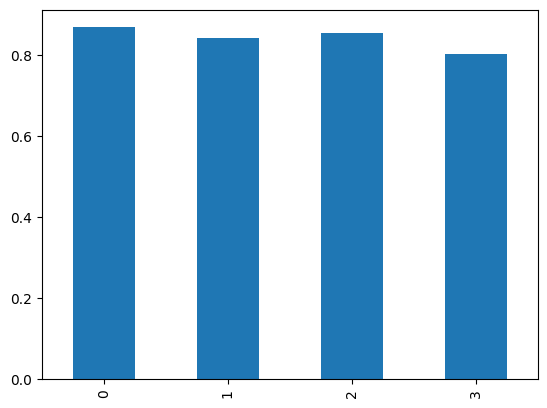

In [32]:
# TODO: show the result visually.
# The plot should compare mean accuracy across CV strategies.

cv_results_df["mean_accuracy"].plot(kind="bar")
#solo nos interesa quedarnos con la columna mean_accuracy


TODO - Write a short interpretation:

```text
The strategy with the highest mean accuracy is... KFold
The strategy I trust most for this problem is... StratifiedKFold
I trust it because... porque se acerca más a una media de los distintos métodos
```

And a short explanation of how the different K-fold variants work:
```text
KFold...Es un cross-validation simple en 5 partes
StratifiedKFold... nos aseguramos de que los alumnos de un mismo grupo no vayan todos a una misma partición.
RepeatedStratifiedKFold... igual, pero con repeticiones y particiones distintas (una por cada n_repeats)
GroupKFold...
```



## 12. Pipeline for preprocessing

If a preprocessing step learns from data, it must be inside the cross-validation loop.

Example: scaling before logistic regression.


In [33]:
# Incorrect pattern: the scaler is fit before cross-validation.
# This allows information from validation folds to influence preprocessing.

scaler = StandardScaler()

# TODO: fit_transform X before CV
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

wrong_scores = cross_val_score(
    LogisticRegression(max_iter=1000), X_scaled, y, cv=cv, scoring="accuracy"
)

wrong_scores.mean()


np.float64(0.9038461538461539)

In [34]:
# Correct pattern: the scaler is inside the Pipeline.
# It is fit separately inside each training fold.

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

pipeline_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
pipeline_scores.mean()


np.float64(0.8423076923076923)